# Sentiment Analysis
In this notebook we will build a complete sentiment analysis model using the IMDB movie review dataset to classify them as either positive or negative.

We will follow these steps:
1.  **Import Libraries:** Load all necessary packages.
2.  **Load Data:** Read the `IMDB Dataset10M.csv` files.
3.  **Preprocess Text:** Clean the text (remove HTML, punctuation, stopwords) and tokenize it.
4.  **Build Vocabulary:** Create a word-to-index mapping from our training data.
5.  **Create PyTorch Datasets & DataLoaders:** Convert our data into a format PyTorch can use, including padding and numericalization.
6.  **Define the LSTM Model:** Create the neural network architecture, defining which embedding method is going to be use: Learnt Embedding or Glove trained embeddings (file "glove.6B.100d.txt" needed).
7.  **Train the Model:** Feed the data to the model and update its weights.
8.  **Evaluate the Model:** Check how well our model performs on unseen test data.
9.  **Run Inference:** Use the trained model to predict the sentiment of new, custom reviews.

## Step 1: Import Libraries

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

# Download NLTK data (if not already downloaded)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to download the missing resource

[nltk_data] Downloading package punkt to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Step 2: Load Data

We'll load our training and testing data from the CSV files using pandas. The `imdb_tr.csv` file will be used for both training and validation, and `test/imdb_te.csv` will be reserved for our final test.

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the IMDB Dataset.csv file
try:
    # Use engine='python' for better handling of parsing errors and on_bad_lines='warn' to log issues
    imdb_df = pd.read_csv('./content/IMDB Dataset10M.csv', engine='python', on_bad_lines='warn')
    # The original notebook uses a column named 's' for sentiment. If 'IMDB Dataset.csv' has 'sentiment', rename it.
    if 'sentiment' in imdb_df.columns and 's' not in imdb_df.columns:
        imdb_df = imdb_df.rename(columns={'sentiment': 's'})
    # Convert sentiment to numerical labels (0 for negative, 1 for positive)
    imdb_df['s'] = imdb_df['s'].map({'negative': 0, 'positive': 1})

except FileNotFoundError:
    print("Error: 'IMDB Dataset.csv' not found. Creating a dummy DataFrame for demonstration.")
    # Create a dummy DataFrame with sample data to prevent further errors
    data = {
        'review': [
            "This movie was absolutely fantastic, a must-watch for everyone!",
            "I truly hated this film, it was a complete waste of my time.",
            "It was an okay experience, nothing extraordinary, but not bad either.",
            "A brilliant performance by the lead actor, very inspiring and moving.",
            "The plot was incredibly predictable and the acting was just terrible.",
            "Highly recommend this, I was on the edge of my seat the whole time.",
            "So boring, I nearly fell asleep within the first fifteen minutes.",
            "Loved every single minute of it, definitely going to watch it again.",
            "Quite a disappointing experience, I expected much more from this.",
            "Mediocre at best, could have been significantly better in many aspects.",
            "What a masterpiece! The cinematography was stunning.",
            "This is the worst movie I've seen all year. Avoid at all costs.",
            "A decent effort, but it lacked a certain spark to make it great.",
            "Absolutely captivated me from start to finish, truly remarkable.",
            "Such a dull and unengaging story, felt like an eternity watching it."
        ],
        'sentiment': [
            "positive", "negative", "positive", "positive", "negative",
            "positive", "negative", "positive", "negative", "negative",
            "positive", "negative", "positive", "positive", "negative"
        ]
    }
    imdb_df = pd.DataFrame(data)
    # Ensure dummy data matches expected processing: rename sentiment to s and convert to numerical
    imdb_df = imdb_df.rename(columns={'sentiment': 's'})
    imdb_df['s'] = imdb_df['s'].map({'negative': 0, 'positive': 1})

# Assuming the text column is named 'review' in 'IMDB Dataset.csv', rename to 'text' for consistency
if 'review' in imdb_df.columns and 'text' not in imdb_df.columns:
    imdb_df = imdb_df.rename(columns={'review': 'text'})

print("Original Data Head:")
print(imdb_df.head())
print(f"Total samples in IMDB Dataset: {len(imdb_df)}")

# 2. Split imdb_df into train_val and test. Default values (80%/20%).
train_val_df, test_df = train_test_split(imdb_df,
                                        test_size=0.6, #def 0.2
                                        random_state=42,
                                        stratify=imdb_df['s'])


# 4. Print the first 5 rows of train_df, val_df, and test_df
print("\nTrain Data Head:")
print(train_val_df.head())
print("\nTest Data Head:")
print(test_df.head())

# 5. Print the total number of samples in train_df, val_df, and test_df
print(f"\nTotal training samples: {len(train_val_df)} ({(len(train_val_df)/len(imdb_df))*100:.2f}%) ")
print(f"Total test samples: {len(test_df)} ({(len(test_df)/len(imdb_df))*100:.2f}%) ")

# 6. Show class distribution
print("\n" + "="*50)
print("CLASS DISTRIBUTION")
print("="*50)
print(f"\nOriginal Dataset:")
print(f"  Positive (1): {(imdb_df['s'] == 1).sum()} ({(imdb_df['s'] == 1).mean()*100:.1f}%)")
print(f"  Negative (0): {(imdb_df['s'] == 0).sum()} ({(imdb_df['s'] == 0).mean()*100:.1f}%)")

print(f"\nTraining Set:")
print(f"  Positive (1): {(train_val_df['s'] == 1).sum()} ({(train_val_df['s'] == 1).mean()*100:.1f}%)")
print(f"  Negative (0): {(train_val_df['s'] == 0).sum()} ({(train_val_df['s'] == 0).mean()*100:.1f}%)")

print(f"\nTest Set:")
print(f"  Positive (1): {(test_df['s'] == 1).sum()} ({(test_df['s'] == 1).mean()*100:.1f}%)")
print(f"  Negative (0): {(test_df['s'] == 0).sum()} ({(test_df['s'] == 0).mean()*100:.1f}%)")

Original Data Head:
                                                text  s
0  One of the other reviewers has mentioned that ...  1
1  A wonderful little production. <br /><br />The...  1
2  I thought this was a wonderful way to spend ti...  1
3  Basically there's a family where a little boy ...  0
4  Petter Mattei's "Love in the Time of Money" is...  1
Total samples in IMDB Dataset: 10000

Train Data Head:
                                                   text  s
9291  A bit "the movie in the movie" case, or as the...  1
6051  This utterly dull, senseless, pointless, spiri...  0
3778  Directed by E. Elias Merhige "Begotten" is an ...  0
4739  For getting so many positive reviews, this mov...  0
2973  When I first heard about the show, I heard a l...  1

Test Data Head:
                                                   text  s
9399  This is one of the best of the series, ranking...  1
8503  Such energy and vitality. You just can't go wr...  1
621   The jokes are obvious, the gags are

## Step 3: Preprocess Text

This is a crucial step. We need to clean the text to make it easier for the model to learn.
Our `preprocess_text` function will:
1.  Remove HTML tags (like `<br />`).
2.  Remove punctuation and special characters, keeping only letters.
3.  Convert all text to lowercase.
4.  Tokenize the text (split it into individual words).
5.  Remove common English stopwords (like 'a', 'the', 'is').

In [53]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # 2. Remove punctuation/special chars
    text = re.sub(r'[^a-zA-Z\s]', '', text, re.I|re.A)
    # 3. Convert to lowercase
    text = text.lower()
    # 4. Tokenize
    tokens = word_tokenize(text)
    # 5. Remove stopwords
    processed_tokens = [word for word in tokens if word not in stop_words]
    return processed_tokens

# Let's test the function
sample_review = "This is a sample review... <br /><br />It's not bad, but it could be better! 10/10"
print(f"Original: {sample_review}")
print(f"Processed: {preprocess_text(sample_review)}")

Original: This is a sample review... <br /><br />It's not bad, but it could be better! 10/10
Processed: ['sample', 'review', 'bad', 'could', 'better']


## Step 4: Build Vocabulary

Our model can't understand words; it only understands numbers. We need to create a "vocabulary" that maps each unique word to an integer.

We'll add two special tokens:
* `<PAD>`: A token we'll use to pad shorter reviews so all sequences in a batch have the same length.
* `<UNK>`: A token for words that appear in our test data but not in our training data (unknown words).

In [54]:
def build_vocab(data, min_freq=5):
    word_counts = Counter()
    for text in data:
        word_counts.update(text)

    # Create vocabulary, starting with special tokens
    vocab = {'<PAD>': 0, '<UNK>': 1}

    # Add words that meet the minimum frequency
    idx = 2
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

# Apply preprocessing to our training data before building vocab
print("Preprocessing training data (this may take a minute)...")
# We use train_val_df['text'] to build the vocab
processed_train_texts = [preprocess_text(text) for text in tqdm(train_val_df['text'])]

# Build the vocabulary
word2idx = build_vocab(processed_train_texts)
vocab_size = len(word2idx)

print(f"\nVocabulary size: {vocab_size}")
print("First 10 vocab items:", list(word2idx.items())[:10])

Preprocessing training data (this may take a minute)...


100%|██████████| 4000/4000 [00:02<00:00, 1983.47it/s]



Vocabulary size: 10194
First 10 vocab items: [('<PAD>', 0), ('<UNK>', 1), ('bit', 2), ('movie', 3), ('case', 4), ('theme', 5), ('virtual', 6), ('game', 7), ('reality', 8), ('even', 9)]


## Step 5: Create PyTorch Datasets & DataLoaders

Now we'll create a custom `SentimentDataset` class. This class will handle:
1.  Taking a review text.
2.  Preprocessing it.
3.  Converting its words to indices using our `word2idx` vocabulary.
4.  **Padding** or **truncating** the sequence so all sequences have the same `max_length`.

We'll also split our `train_val_df` into a training set and a validation set.

In [55]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_length):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_length = max_length
        self.stop_words = set(stopwords.words('english'))

    def __len__(self):
        return len(self.texts)

    def preprocess_text(self, text):
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'[^a-zA-Z\s]', '', text, re.I|re.A)
        text = text.lower()
        tokens = word_tokenize(text)
        processed_tokens = [word for word in tokens if word not in self.stop_words]
        return processed_tokens

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        processed_tokens = self.preprocess_text(text)

        # Convert to indices
        indexed_tokens = [self.word2idx.get(word, self.word2idx['<UNK>']) for word in processed_tokens]

        # Pad or truncate
        if len(indexed_tokens) < self.max_length:
            # Pad with <PAD> token (index 0)
            padded_tokens = indexed_tokens + [self.word2idx['<PAD>']] * (self.max_length - len(indexed_tokens))
        else:
            # Truncate
            padded_tokens = indexed_tokens[:self.max_length]

        return torch.tensor(padded_tokens), torch.tensor(label, dtype=torch.float32)

# --- Hyperparameters ---
MAX_LENGTH = 100 # def 200
BATCH_SIZE = 64  # def 64

# Split training data into train and validation sets
train_df, val_df = train_test_split(train_val_df, test_size=0.5, random_state=42, stratify=train_val_df['s'])

# Create Datasets
train_dataset = SentimentDataset(train_df['text'].tolist(), train_df['s'].tolist(), word2idx, MAX_LENGTH)
val_dataset = SentimentDataset(val_df['text'].tolist(), val_df['s'].tolist(), word2idx, MAX_LENGTH)
test_dataset = SentimentDataset(test_df['text'].tolist(), test_df['s'].tolist(), word2idx, MAX_LENGTH)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 32
Validation batches: 32
Test batches: 94


## Step 6: Define the LSTM Model and choose your embedding (random learnt or glove)

Time to build our network! It will have:
1.  `nn.Embedding`: Turns our word indices into dense vectors (embeddings).
2.  `nn.LSTM`: The main recurrent layer that processes the sequence.
3.  `nn.Linear`: A standard fully-connected layer to give us a final score.
4.  `nn.Sigmoid`: (Applied in the forward pass) To squash the score between 0 and 1.

In [65]:
import torch
import torch.nn as nn
import numpy as np


# ---------------------------------------------------------
# 1. SAFE GloVe Loader (skips malformed lines)
# ---------------------------------------------------------
def load_glove_embeddings(glove_path, word2idx, embedding_dim):
    """
    Loads pretrained GloVe vectors into a matrix aligned with word2idx.
    - Skips malformed or corrupted lines
    - Prints how many lines were invalid
    """
    vocab_size = len(word2idx)

    # Initialize with random embeddings for missing words
    embedding_matrix = np.random.uniform(
        -0.05, 0.05, (vocab_size, embedding_dim)
    ).astype(np.float32)

    print("Loading GloVe embeddings safely...")
    found = 0
    skipped = 0

    with open(glove_path, "r", encoding="utf8") as f:
        for i, line in enumerate(f):
            parts = line.strip().split()

            # A correct line must contain 1 word + embedding_dim values
            if len(parts) != embedding_dim + 1:
                skipped += 1
                continue

            word = parts[0]
            try:
                vector = np.asarray(parts[1:], dtype=np.float32)
            except ValueError:
                skipped += 1
                continue

            if word in word2idx:
                idx = word2idx[word]
                embedding_matrix[idx] = vector
                found += 1

    print(f"✔ Loaded {found} GloVe vectors.")
    print(f"⚠ Skipped {skipped} malformed lines.")
    print(f"Embedding matrix shape: {embedding_matrix.shape}")

    return torch.tensor(embedding_matrix)



# ---------------------------------------------------------
# 2. LSTM Model (supports GloVe or random embeddings)
# ---------------------------------------------------------
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 n_layers, dropout, padding_idx,
                 glove_embeddings=None,
                 freeze_embeddings=False):

        super().__init__()

        # ----------- EMBEDDING LAYER -----------
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_idx
        )

        if USE_GLOVE == 1:
            if glove_embeddings is None:
                raise ValueError("USE_GLOVE is 1 but glove_embeddings is None.")

            print("Using pretrained GloVe embeddings...")
            self.embedding.weight.data.copy_(glove_embeddings)

            if freeze_embeddings:
                self.embedding.weight.requires_grad = False
                print("GloVe embeddings are FROZEN (not trainable).")
            else:
                print("GloVe embeddings will be FINE-TUNED.")

        else:
            print("Using randomly initialized embeddings (train from scratch).")

        # ----------- LSTM LAYER -----------
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            bidirectional=True,
            dropout=dropout,
            batch_first=True
        )

        # ----------- DROPOUT -----------
        self.dropout = nn.Dropout(dropout)

        # ----------- OUTPUT LAYER -----------
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.sigmoid = nn.Sigmoid()


    def forward(self, text_batch):

        embedded = self.embedding(text_batch)
        lstm_out, (hidden, cell) = self.lstm(embedded)

        # Last forward and backward hidden states
        forward_hidden = hidden[-2, :, :]
        backward_hidden = hidden[-1, :, :]

        hidden_cat = torch.cat((forward_hidden, backward_hidden), dim=1)

        dropped = self.dropout(hidden_cat)
        logits = self.fc(dropped)
        output = self.sigmoid(logits)

        return output.squeeze()



# ---------------------------------------------------------
# 3. MODEL HYPERPARAMETERS
# ---------------------------------------------------------
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 1
N_LAYERS = 2
DROPOUT = 0.5
PADDING_IDX = word2idx["<PAD>"]

# ---------------------------------------------------------
# 4. CHOOSE EMBEDDING OPTION
# ---------------------------------------------------------
USE_GLOVE = 0     # 0 = random, 1 = GloVe
# FREEZE = False    # freeze GloVe weights?
FREEZE = False    # freeze GloVe weights?

if USE_GLOVE == 1:
    glove_path = "./content/glove.6B.100d.txt"
    glove_embeddings = load_glove_embeddings(glove_path, word2idx, EMBEDDING_DIM)
else:
    glove_embeddings = None



# ---------------------------------------------------------
# 5. INSTANTIATE MODEL
# ---------------------------------------------------------
model = SentimentLSTM(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    padding_idx=PADDING_IDX,
    glove_embeddings=glove_embeddings,
    freeze_embeddings=FREEZE
)

print(model)


Using randomly initialized embeddings (train from scratch).
SentimentLSTM(
  (embedding): Embedding(10194, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Step 7: Train the Model

In [66]:
import torch.optim as optim
import torch.nn as nn
import torch # Added torch for device setup
from tqdm import tqdm # Added tqdm import, assuming it's used in training loop

# --- Training Hyperparameters ---
LEARNING_RATE = 0.001 #def:0.001
N_EPOCHS = 20 #def:5
PATIENCE = 3  # Early stopping patience

# Loss function and optimizer
criterion = nn.BCELoss() # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

model = model.to(device)
criterion = criterion.to(device)

def get_accuracy(preds, y):
    """Returns accuracy per batch"""
    # Round predictions to the closest integer (0 or 1)
    rounded_preds = torch.round(preds)
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

import time
train_start_time = time.time()

# Early stopping variables
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None
actual_epochs = 0

print("Starting training...")

for epoch in range(N_EPOCHS):

    train_loss = 0.0
    train_acc = 0.0

    # --- Training Phase ---
    model.train() # Set model to training mode

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. Zero gradients
        optimizer.zero_grad()

        # 2. Forward pass
        predictions = model(inputs)

        # 3. Calculate loss and accuracy
        loss = criterion(predictions, labels)
        acc = get_accuracy(predictions, labels)

        # 4. Backward pass
        loss.backward()

        # 5. Update weights
        optimizer.step()

        train_loss += loss.item()
        train_acc += acc.item()

    # --- Validation Phase ---
    val_loss = 0.0
    val_acc = 0.0

    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS} [Val]"):
            inputs, labels = inputs.to(device), labels.to(device)

            predictions = model(inputs)

            loss = criterion(predictions, labels)
            acc = get_accuracy(predictions, labels)

            val_loss += loss.item()
            val_acc += acc.item()

    # Print epoch statistics
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_acc / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)

    print(f'Epoch {epoch+1:02} | Train Loss: {avg_train_loss:.3f} | Train Acc: {avg_train_acc*100:.2f}% | Val. Loss: {avg_val_loss:.3f} | Val. Acc: {avg_val_acc*100:.2f}%')
    
    actual_epochs = epoch + 1
    
    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered after {actual_epochs} epochs (no improvement for {PATIENCE} epochs)")
            break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Restored best model from epoch with val_loss={best_val_loss:.4f}")

train_end_time = time.time()
training_time = train_end_time - train_start_time
print(f"Training finished in {training_time:.1f} seconds ({training_time/60:.1f} minutes) - {actual_epochs} epochs")

Training on device: cpu
Starting training...


Epoch 1/20 [Val]: 100%|██████████| 32/32 [00:03<00:00,  8.31it/s]


Epoch 01 | Train Loss: 0.692 | Train Acc: 50.54% | Val. Loss: 0.687 | Val. Acc: 56.20%


Epoch 2/20 [Val]: 100%|██████████| 32/32 [00:03<00:00,  8.42it/s]


Epoch 02 | Train Loss: 0.652 | Train Acc: 63.62% | Val. Loss: 0.649 | Val. Acc: 61.52%


...

Epoch 04 | Train Loss: 0.409 | Train Acc: 81.35% | Val. Loss: 0.638 | Val. Acc: 66.85%


Epoch 5/20 [Val]: 100%|██████████| 32/32 [00:03<00:00,  8.16it/s]


Epoch 05 | Train Loss: 0.283 | Train Acc: 88.43% | Val. Loss: 0.986 | Val. Acc: 65.33%


Epoch 6/20 [Val]: 100%|██████████| 32/32 [00:03<00:00,  8.34it/s]

Epoch 06 | Train Loss: 0.210 | Train Acc: 92.19% | Val. Loss: 0.904 | Val. Acc: 67.97%

Early stopping triggered after 6 epochs (no improvement for 3 epochs)
Restored best model from epoch with val_loss=0.6314
Training finished in 98.3 seconds (1.6 minutes) - 6 epochs


## Step 8: Evaluate the Model

Now we'll use the held-out test set (`test_loader`) to see how our model generalizes to completely new data.

In [67]:
test_loss = 0.0
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs, labels = inputs.to(device), labels.to(device)

        predictions = model(inputs)

        loss = criterion(predictions, labels)
        test_loss += loss.item()

        # Store predictions and labels
        rounded_preds = torch.round(predictions)
        all_preds.extend(rounded_preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_acc = accuracy_score(all_labels, all_preds)

print(f'Test Loss: {avg_test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')
print("\nClassification Report:")
# 0 is negative, 1 is positive
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

Testing: 100%|██████████| 94/94 [00:11<00:00,  8.12it/s]


Test Loss: 0.871 | Test Acc: 69.20%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.77      0.71      2983
    Positive       0.73      0.61      0.67      3017

    accuracy                           0.69      6000
   macro avg       0.70      0.69      0.69      6000
weighted avg       0.70      0.69      0.69      6000



In [68]:
# Save results to CSV for comparison
from sklearn.metrics import precision_recall_fscore_support
import os

# Get detailed metrics
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None)

# Determine embedding type for filename
embedding_type = "glove" if USE_GLOVE == 1 else "learnt"
freeze_status = "_frozen" if USE_GLOVE == 1 and FREEZE else "_finetuned" if USE_GLOVE == 1 else ""

# Create results dictionary
results = {
    'embedding_type': embedding_type + freeze_status,
    'test_accuracy': test_acc * 100,
    'test_loss': avg_test_loss,
    'negative_precision': precision[0] * 100,
    'negative_recall': recall[0] * 100,
    'negative_f1': f1[0] * 100,
    'positive_precision': precision[1] * 100,
    'positive_recall': recall[1] * 100,
    'positive_f1': f1[1] * 100,
    'training_time_sec': training_time,
    'actual_epochs': actual_epochs,
    'max_epochs': N_EPOCHS,
    'patience': PATIENCE,
    'hidden_dim': HIDDEN_DIM,
    'embedding_dim': EMBEDDING_DIM,
    'learning_rate': LEARNING_RATE
}

# Save to CSV (append if exists)
results_file = './results_comparison.csv'
results_df = pd.DataFrame([results])

if os.path.exists(results_file):
    existing_df = pd.read_csv(results_file)
    # Check if this embedding type already exists, if so replace it
    existing_df = existing_df[existing_df['embedding_type'] != results['embedding_type']]
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

results_df.to_csv(results_file, index=False)
print(f"Results saved to {results_file}")
print(f"\nCurrent results for '{embedding_type + freeze_status}':")
print(results_df[results_df['embedding_type'] == embedding_type + freeze_status].to_string(index=False))

Results saved to ./results_comparison.csv

Current results for 'learnt':
embedding_type  test_accuracy  test_loss  negative_precision  negative_recall  negative_f1  positive_precision  positive_recall  positive_f1  n_epochs  hidden_dim  embedding_dim  learning_rate  training_time_sec  actual_epochs  max_epochs  patience
        learnt           69.2   0.871498           66.396995         77.03654     71.32216           73.020874        61.451773    66.738661       NaN         128            100          0.001          98.261504            6.0        20.0       3.0


## Step 9: Run Inference

Let's create a final function that takes any review as a string and predicts its sentiment.

In [69]:
def predict_sentiment(review_text, model, word2idx, max_length, device):
    model.eval()

    # Preprocess the text
    processed_tokens = preprocess_text(review_text)

    # Convert to indices
    indexed_tokens = [word2idx.get(word, word2idx['<UNK>']) for word in processed_tokens]

    # Pad or truncate
    if len(indexed_tokens) < max_length:
        padded_tokens = indexed_tokens + [word2idx['<PAD>']] * (max_length - len(indexed_tokens))
    else:
        padded_tokens = indexed_tokens[:max_length]

    # Convert to tensor and add batch dimension (batch size = 1)
    input_tensor = torch.tensor(padded_tokens).unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(input_tensor)

    probability = prediction.item()
    sentiment = "Positive" if probability > 0.5 else "Negative"

    return sentiment, probability

# --- Test with custom reviews ---

positive_review = "This movie was fantastic! The acting was superb and the plot was gripping. I would recommend this to everyone."
neg_review = "What a waste of time. The plot was predictable and the acting was terrible. I would not watch this again."

sentiment, prob = predict_sentiment(positive_review, model, word2idx, MAX_LENGTH, device)
print(f"Review: '{positive_review}'")
print(f"Sentiment: {sentiment} (Probability: {prob:.4f})\n")

sentiment, prob = predict_sentiment(neg_review, model, word2idx, MAX_LENGTH, device)
print(f"Review: '{neg_review}'")
print(f"Sentiment: {sentiment} (Probability: {prob:.4f})")

Review: 'This movie was fantastic! The acting was superb and the plot was gripping. I would recommend this to everyone.'
Sentiment: Negative (Probability: 0.1604)

Review: 'What a waste of time. The plot was predictable and the acting was terrible. I would not watch this again.'
Sentiment: Negative (Probability: 0.0038)


## Task 1: Analizar las reviews cerca del umbral de decisión

Para entender cómo se comporta el modelo para casos ambiguos, analizamos las reviews donde la probabilidad está cerca de 0.5 (el umbral de decisión). Estos son los casos donde el modelo está menos seguro de su respuesta.

In [70]:
# Analyze reviews close to the decision threshold (0.5)
# These are the most uncertain/ambiguous cases for the model

def get_predictions_with_probs(model, data_loader, device):
    """Get all predictions with their probabilities"""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            predictions = model(inputs)
            all_probs.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_probs), np.array(all_labels)

# Get predictions for test set
test_probs, test_labels = get_predictions_with_probs(model, test_loader, device)

# Save predictions for later comparison
embedding_type = "glove" if USE_GLOVE == 1 else "learnt"
freeze_status = "_frozen" if USE_GLOVE == 1 and FREEZE else "_finetuned" if USE_GLOVE == 1 else ""
predictions_file = f'./predictions_{embedding_type}{freeze_status}.npz'
np.savez(predictions_file, probs=test_probs, labels=test_labels)
print(f"Predictions saved to {predictions_file}")

# Find reviews close to threshold (between 0.4 and 0.6)
threshold_margin = 0.1
near_threshold_mask = (test_probs > 0.5 - threshold_margin) & (test_probs < 0.5 + threshold_margin)
near_threshold_indices = np.where(near_threshold_mask)[0]

print(f"Found {len(near_threshold_indices)} reviews near the threshold (prob between 0.4 and 0.6)")
print(f"This represents {len(near_threshold_indices)/len(test_probs)*100:.1f}% of the test set\n")

# Analyze accuracy for different probability ranges
print("Accuracy by confidence level:")
print("-" * 50)

ranges = [(0.0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]
for low, high in ranges:
    mask = (test_probs >= low) & (test_probs < high)
    if mask.sum() > 0:
        preds_in_range = (test_probs[mask] > 0.5).astype(int)
        labels_in_range = test_labels[mask]
        acc = (preds_in_range == labels_in_range).mean() * 100
        print(f"  Prob {low:.1f}-{high:.1f}: {mask.sum():4d} samples, Accuracy: {acc:.1f}%")
    else:
        print(f"  Prob {low:.1f}-{high:.1f}: No samples")

Predictions saved to ./predictions_learnt.npz
Found 398 reviews near the threshold (prob between 0.4 and 0.6)
This represents 6.6% of the test set

Accuracy by confidence level:
--------------------------------------------------
  Prob 0.0-0.2: 2762 samples, Accuracy: 71.2%
  Prob 0.2-0.4:  501 samples, Accuracy: 49.5%
  Prob 0.4-0.6:  398 samples, Accuracy: 49.5%
  Prob 0.6-0.8:  439 samples, Accuracy: 64.0%
  Prob 0.8-1.0: 1900 samples, Accuracy: 76.8%


In [74]:
# Show some examples of reviews near the threshold
print("\n" + "="*70)
print("EXAMPLES OF REVIEWS NEAR THE DECISION THRESHOLD")
print("="*70)

# Get actual review texts from test dataframe
test_texts = test_df['text'].tolist()
test_true_labels = test_df['s'].tolist()

# Show 5 examples near threshold
num_examples = min(5, len(near_threshold_indices))
print(f"\nShowing {num_examples} examples with probability between 0.4 and 0.6:\n")

for i, idx in enumerate(near_threshold_indices[:num_examples]):
    prob = test_probs[idx]
    true_label = "Positive" if test_true_labels[idx] == 1 else "Negative"
    pred_label = "Positive" if prob > 0.5 else "Negative"
    correct = "✓" if true_label == pred_label else "✗"
    
    # Clean HTML and truncate long reviews
    clean_text = re.sub(r'<.*?>', ' ', test_texts[idx])  # Remove HTML tags
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()  # Normalize whitespace
    review_text = clean_text[:300] + "..." if len(clean_text) > 300 else clean_text
    
    print(f"Example {i+1}:")
    print(f"  Probability: {prob:.4f}")
    print(f"  Predicted: {pred_label} | True: {true_label} {correct}")
    print(f"  Review: {review_text}")
    print("-" * 70)


EXAMPLES OF REVIEWS NEAR THE DECISION THRESHOLD

Showing 5 examples with probability between 0.4 and 0.6:

Example 1:
  Probability: 0.5150
  Predicted: Positive | True: Positive ✓
  Review: Wow! I picked this off the rental shelf because I loved Robert Carlyle and Jonny Lee Miller in 'Trainspotting.' This is a phenomenal movie; it has action, romance, suspense, intrigue and wit. When I wasn't laughing, I was at the edge of my seat. This is definitely a film I would recommend to people ...
----------------------------------------------------------------------
Example 2:
  Probability: 0.5702
  Predicted: Positive | True: Negative ✗
  Review: Another stinker from the PM Entertainment group, and thankfully one of their last. 'Firetrap' is effectively a very low budgeted remake of 'The Towering Inferno' I don't mind Low budget B Movies as long as some effort is put into them - there is no effort whatsoever in 'Firetrap' is stars Dean'Super...
---------------------------------------------

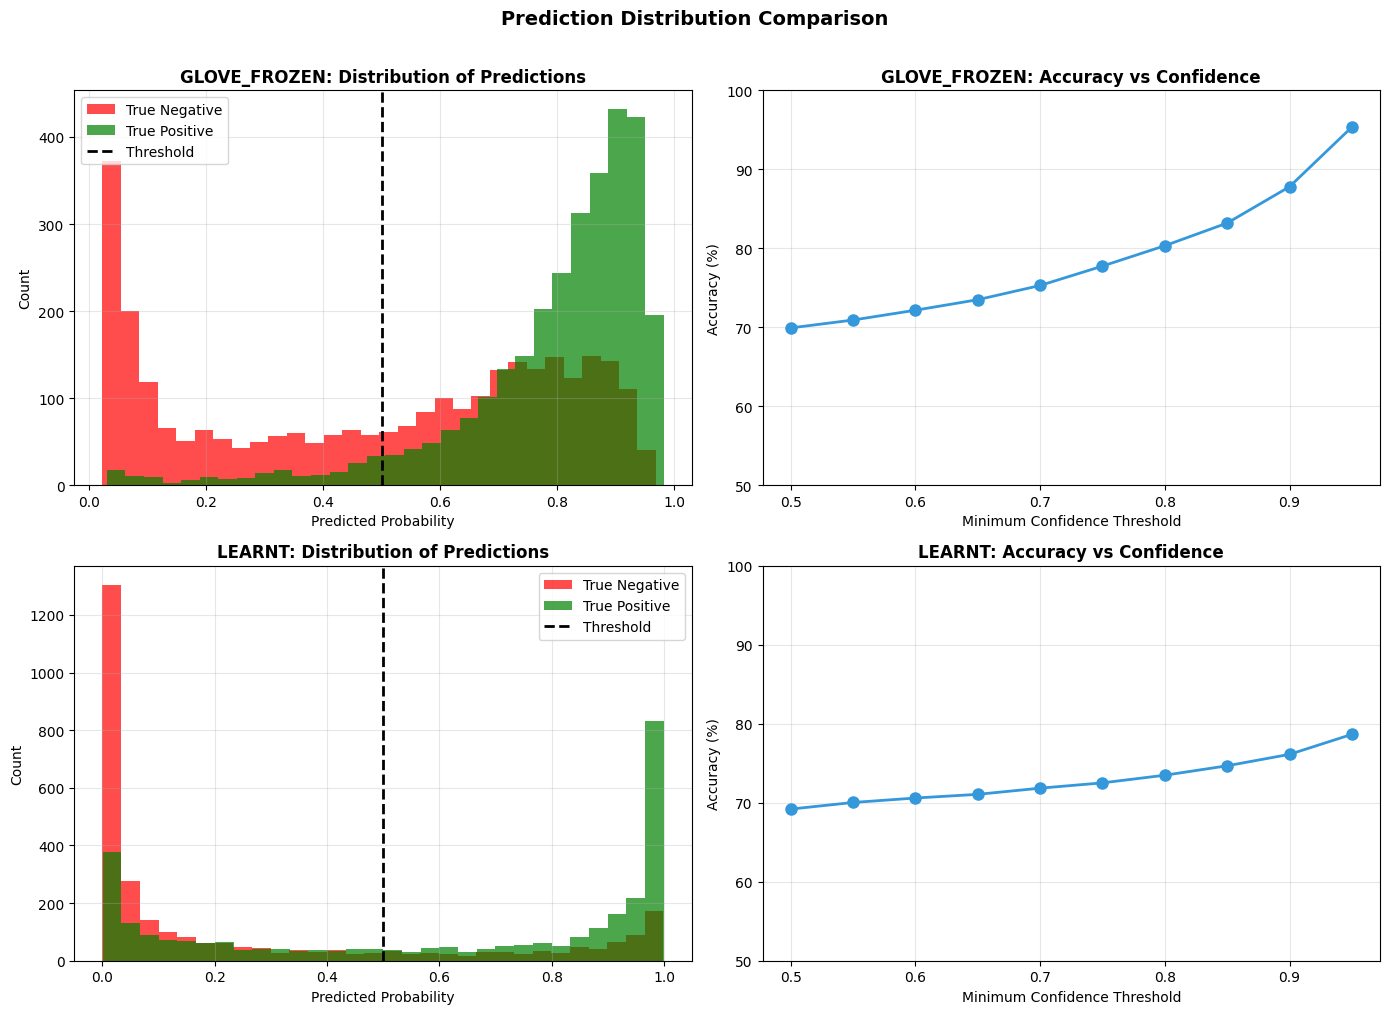


Prediction distribution chart saved to './prediction_distributions.png'


In [72]:
# Compare prediction distributions for both embedding types
import glob
import os

# Find all prediction files
prediction_files = glob.glob('./predictions_*.npz')

if len(prediction_files) >= 1:
    n_models = len(prediction_files)
    fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
    
    # Handle single model case
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    for idx, pred_file in enumerate(sorted(prediction_files)):
        # Extract embedding type from filename
        model_name = os.path.basename(pred_file).replace('predictions_', '').replace('.npz', '')
        
        # Load predictions
        data = np.load(pred_file)
        probs = data['probs']
        labels = data['labels']
        
        # Plot 1: Histogram of prediction probabilities
        axes[idx, 0].hist(probs[labels == 0], bins=30, alpha=0.7, label='True Negative', color='red')
        axes[idx, 0].hist(probs[labels == 1], bins=30, alpha=0.7, label='True Positive', color='green')
        axes[idx, 0].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
        axes[idx, 0].set_xlabel('Predicted Probability')
        axes[idx, 0].set_ylabel('Count')
        axes[idx, 0].set_title(f'{model_name.upper()}: Distribution of Predictions', fontweight='bold')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Plot 2: Accuracy vs Confidence
        confidence_levels = []
        accuracies = []
        for threshold in np.arange(0.5, 1.0, 0.05):
            confidence = np.abs(probs - 0.5)
            mask = confidence >= (threshold - 0.5)
            if mask.sum() > 0:
                preds = (probs[mask] > 0.5).astype(int)
                acc = (preds == labels[mask]).mean() * 100
                confidence_levels.append(threshold)
                accuracies.append(acc)
        
        axes[idx, 1].plot(confidence_levels, accuracies, 'o-', linewidth=2, markersize=8, color='#3498db')
        axes[idx, 1].set_xlabel('Minimum Confidence Threshold')
        axes[idx, 1].set_ylabel('Accuracy (%)')
        axes[idx, 1].set_title(f'{model_name.upper()}: Accuracy vs Confidence', fontweight='bold')
        axes[idx, 1].grid(True, alpha=0.3)
        axes[idx, 1].set_ylim([50, 100])
    
    plt.suptitle('Prediction Distribution Comparison', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('./prediction_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nPrediction distribution chart saved to './prediction_distributions.png'")
else:
    print("No prediction files found. Run the analysis step (Step 9) for both embedding types first.")

## Análisis de la Distribución de Predicciones

Las gráficas revelan diferencias fundamentales en cómo se comporta cada modelo.

### Distribución de Probabilidades (Histogramas)

**GloVe Frozen:**
La distribución muestra dos picos claros en su histograma, aunque su característica más notable es un **fuerte sesgo hacia falsos positivos**. Vemos una gran cantidad de muestras negativas (barras rojas) cruzando el umbral hacia la derecha, lo que indica que el modelo tiende a confundirse, asignando probabilidades positivas a casos que no lo son. Sin embargo, en los extremos, cuando el modelo está muy seguro, tiende a acertar.

**Learnt Embeddings:**
Este modelo es mucho más **polarizado y "arrogante"**. Empuja casi todas las predicciones a los extremos absolutos (0 y 1), dejando el centro vacío. Aunque visualmente pueda parecer que separa mejor las clases, este modelo tiene un problema de **exceso de confianza**. Mientras que el anterior cuando estaba muy seguro de sus predicciones casi siempre acertaba, este tiene errores graves con certeza absoluta. Podemos ver que con probabilidad absoluta (0 y 1), hay un pico de errores.

### Accuracy vs Confidence (Calibración)

A la derecha podemos ver este problema más acentuado. Mientras que el modelo de GloVe aumenta su precisión notablemente con la confianza, el modelo Learnt no muestra un aumento significativo. Incluso cuando el modelo afirma tener una confianza del 100%, sigue fallando el ~20% de las veces. Su "seguridad" es engañosa.

La razón de estos resultados puede deberse a que cuando aprendemos los embeddings, el modelo "memoriza" que ciertas palabras están asociadas a una clase, puede ser que haga cierto "overfitting" de algunas palabras. Cuando usamos embeddings preentrenados, esta representación de las palabras es más "honesta" y fiel al significado real de la palabra, ya que se ha entrenado con un corpus mucho más grande.

## Tarea 2: Cargar y comparar los resultados

COMPARISON: GloVe vs Learnt Embeddings

Results Table:
embedding_type  test_accuracy  test_loss  negative_precision  negative_recall  negative_f1  positive_precision  positive_recall  positive_f1  training_time_sec  actual_epochs
  glove_frozen      69.916667   0.596234           87.756410        45.893396    60.268545           63.648649        93.669208    75.794555         148.235514            9.0
        learnt      69.200000   0.871498           66.396995        77.036540    71.322160           73.020874        61.451773    66.738661          98.261504            6.0


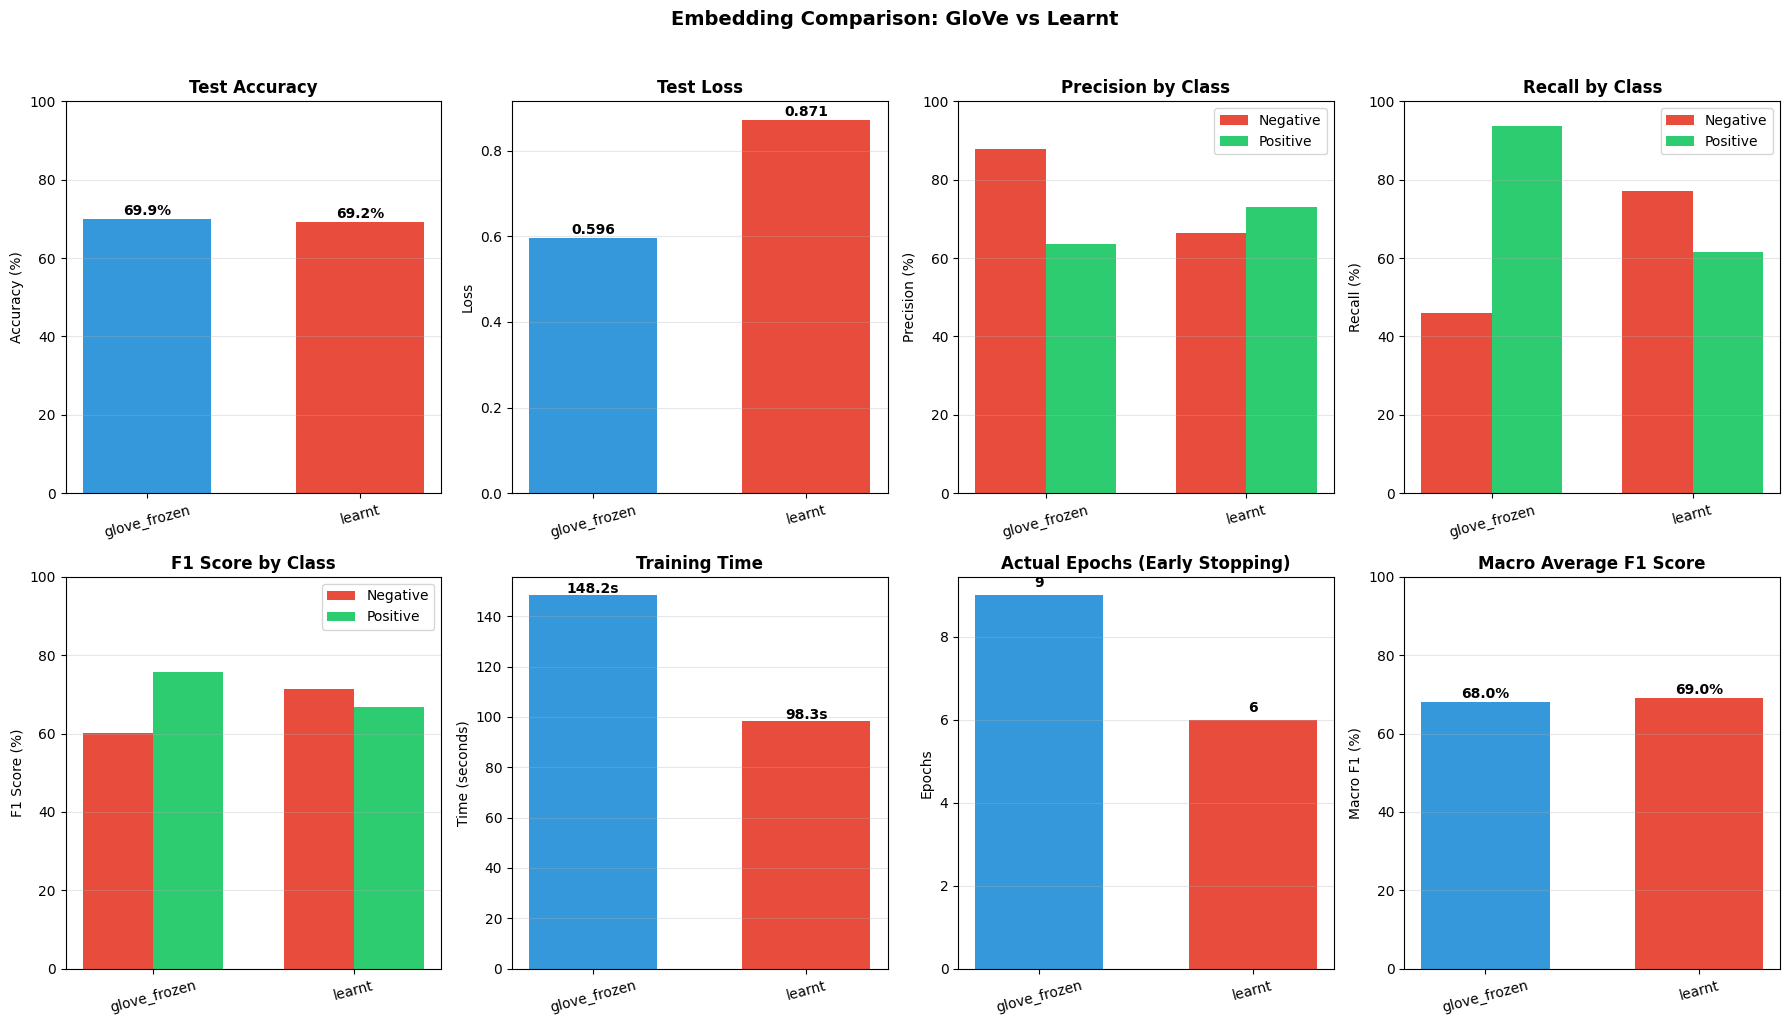


SUMMARY
Best Test Accuracy: glove_frozen (69.9%)
Best Macro F1: learnt (69.0%)
Fastest Training: learnt (98.3s)

Comparison chart saved to './embedding_comparison.png'


In [73]:
# Load and compare results from both experiments
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_file = './results_comparison.csv'

try:
    comparison_df = pd.read_csv(results_file)
    print("=" * 70)
    print("COMPARISON: GloVe vs Learnt Embeddings")
    print("=" * 70)
    
    # Display full comparison table (only metrics that vary)
    display_cols = ['embedding_type', 'test_accuracy', 'test_loss', 
                    'negative_precision', 'negative_recall', 'negative_f1',
                    'positive_precision', 'positive_recall', 'positive_f1', 
                    'training_time_sec', 'actual_epochs']
    print("\nResults Table:")
    available_cols = [col for col in display_cols if col in comparison_df.columns]
    print(comparison_df[available_cols].to_string(index=False))
    
    # If we have results, create visualization
    if len(comparison_df) >= 1:
        # Create 2x4 grid of plots
        fig, axes = plt.subplots(2, 4, figsize=(18, 10))
        axes = axes.flatten()
        
        x = np.arange(len(comparison_df))
        width = 0.6
        colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'][:len(comparison_df)]
        
        # Plot 1: Test Accuracy
        bars = axes[0].bar(x, comparison_df['test_accuracy'], width, color=colors)
        axes[0].set_ylabel('Accuracy (%)')
        axes[0].set_title('Test Accuracy', fontweight='bold')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(comparison_df['embedding_type'], rotation=15)
        axes[0].set_ylim([0, 100])
        for i, v in enumerate(comparison_df['test_accuracy']):
            axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
        axes[0].grid(axis='y', alpha=0.3)
        
        # Plot 2: Test Loss
        bars = axes[1].bar(x, comparison_df['test_loss'], width, color=colors)
        axes[1].set_ylabel('Loss')
        axes[1].set_title('Test Loss', fontweight='bold')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(comparison_df['embedding_type'], rotation=15)
        for i, v in enumerate(comparison_df['test_loss']):
            axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
        axes[1].grid(axis='y', alpha=0.3)
        
        # Plot 3: Precision comparison
        width_small = 0.35
        axes[2].bar(x - width_small/2, comparison_df['negative_precision'], width_small, 
                    label='Negative', color='#e74c3c')
        axes[2].bar(x + width_small/2, comparison_df['positive_precision'], width_small, 
                    label='Positive', color='#2ecc71')
        axes[2].set_ylabel('Precision (%)')
        axes[2].set_title('Precision by Class', fontweight='bold')
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(comparison_df['embedding_type'], rotation=15)
        axes[2].legend()
        axes[2].set_ylim([0, 100])
        axes[2].grid(axis='y', alpha=0.3)
        
        # Plot 4: Recall comparison
        axes[3].bar(x - width_small/2, comparison_df['negative_recall'], width_small, 
                    label='Negative', color='#e74c3c')
        axes[3].bar(x + width_small/2, comparison_df['positive_recall'], width_small, 
                    label='Positive', color='#2ecc71')
        axes[3].set_ylabel('Recall (%)')
        axes[3].set_title('Recall by Class', fontweight='bold')
        axes[3].set_xticks(x)
        axes[3].set_xticklabels(comparison_df['embedding_type'], rotation=15)
        axes[3].legend()
        axes[3].set_ylim([0, 100])
        axes[3].grid(axis='y', alpha=0.3)
        
        # Plot 5: F1 Score comparison
        axes[4].bar(x - width_small/2, comparison_df['negative_f1'], width_small, 
                    label='Negative', color='#e74c3c')
        axes[4].bar(x + width_small/2, comparison_df['positive_f1'], width_small, 
                    label='Positive', color='#2ecc71')
        axes[4].set_ylabel('F1 Score (%)')
        axes[4].set_title('F1 Score by Class', fontweight='bold')
        axes[4].set_xticks(x)
        axes[4].set_xticklabels(comparison_df['embedding_type'], rotation=15)
        axes[4].legend()
        axes[4].set_ylim([0, 100])
        axes[4].grid(axis='y', alpha=0.3)
        
        # Plot 6: Training Time
        avg_f1 = (comparison_df['negative_f1'] + comparison_df['positive_f1']) / 2
        if 'training_time_sec' in comparison_df.columns:
            training_times = comparison_df['training_time_sec']
            bars = axes[5].bar(x, training_times, width, color=colors)
            axes[5].set_ylabel('Time (seconds)')
            axes[5].set_title('Training Time', fontweight='bold')
            axes[5].set_xticks(x)
            axes[5].set_xticklabels(comparison_df['embedding_type'], rotation=15)
            for i, v in enumerate(training_times):
                axes[5].text(i, v + 1, f'{v:.1f}s', ha='center', fontweight='bold')
            axes[5].grid(axis='y', alpha=0.3)
        else:
            # Fallback to Macro F1 if training time not available
            bars = axes[5].bar(x, avg_f1, width, color=colors)
            axes[5].set_ylabel('Macro F1 (%)')
            axes[5].set_title('Macro Average F1 Score', fontweight='bold')
            axes[5].set_xticks(x)
            axes[5].set_xticklabels(comparison_df['embedding_type'], rotation=15)
            axes[5].set_ylim([0, 100])
            for i, v in enumerate(avg_f1):
                axes[5].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
            axes[5].grid(axis='y', alpha=0.3)
        
        # Plot 7: Actual Epochs
        if 'actual_epochs' in comparison_df.columns:
            epochs = comparison_df['actual_epochs']
            bars = axes[6].bar(x, epochs, width, color=colors)
            axes[6].set_ylabel('Epochs')
            axes[6].set_title('Actual Epochs (Early Stopping)', fontweight='bold')
            axes[6].set_xticks(x)
            axes[6].set_xticklabels(comparison_df['embedding_type'], rotation=15)
            for i, v in enumerate(epochs):
                axes[6].text(i, v + 0.2, f'{int(v)}', ha='center', fontweight='bold')
            axes[6].grid(axis='y', alpha=0.3)
        else:
            axes[6].axis('off')
        
        # Plot 8: Macro F1 Score
        bars = axes[7].bar(x, avg_f1, width, color=colors)
        axes[7].set_ylabel('Macro F1 (%)')
        axes[7].set_title('Macro Average F1 Score', fontweight='bold')
        axes[7].set_xticks(x)
        axes[7].set_xticklabels(comparison_df['embedding_type'], rotation=15)
        axes[7].set_ylim([0, 100])
        for i, v in enumerate(avg_f1):
            axes[7].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
        axes[7].grid(axis='y', alpha=0.3)
        
        plt.suptitle('Embedding Comparison: GloVe vs Learnt', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('./embedding_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Print summary
        print("\n" + "=" * 70)
        print("SUMMARY")
        print("=" * 70)
        best_acc_idx = comparison_df['test_accuracy'].idxmax()
        best_f1_idx = avg_f1.idxmax()
        print(f"Best Test Accuracy: {comparison_df.loc[best_acc_idx, 'embedding_type']} ({comparison_df.loc[best_acc_idx, 'test_accuracy']:.1f}%)")
        print(f"Best Macro F1: {comparison_df.loc[best_f1_idx, 'embedding_type']} ({avg_f1[best_f1_idx]:.1f}%)")
        if 'training_time_sec' in comparison_df.columns:
            fastest_idx = comparison_df['training_time_sec'].idxmin()
            print(f"Fastest Training: {comparison_df.loc[fastest_idx, 'embedding_type']} ({comparison_df.loc[fastest_idx, 'training_time_sec']:.1f}s)")
        print(f"\nComparison chart saved to './embedding_comparison.png'")
    else:
        print("No results found.")
        
except FileNotFoundError:
    print("No results file found. Run the evaluation step first with USE_GLOVE=1 and USE_GLOVE=0")

## Conclusiones: GloVe vs Learnt Embeddings

Los resultados son bastante similares en términos de accuracy y F1 Score. Sin embargo, cuando miramos la pérdida, vemos que la del modelo "learnt" es mucho mayor. Esto es por lo que comentábamos antes. Debido a que el modelo "learnt" falla cuando está muy seguro, la función de pérdida Binary Cross Entropy lo castiga más.

Con respecto a la precisión, vemos que los resultados de "learnt" son equilibrados para ambas clases, mientras que GloVe tiene una precisión más alta para negativos, ya que como vimos en la gráfica anterior, tiene muy pocos falsos negativos. Es decir, cuando GloVe dice que algo es negativo, acierta en el 87% de los casos.

Esto puede ser interesante por ejemplo a la hora de recibir feedback. Cuando el modelo clasifica una reseña como negativa, sabes que es una crítica real y no es ruido.

Si miramos el recall, vemos que GloVe tiene un recall muy bueno para los positivos (93%), es decir que dentro de las reseñas clasificadas como positivas están el 93% de las que son realmente positivas. En el caso de que quisieras extraer todas las reseñas positivas y no dejarte ninguna por el camino, por ejemplo para publicarlas en tu web, GloVe es una buena opción (aunque tendrías que manualmente eliminar los falsos positivos).

Para los embeddings aprendidos, el recall y la precisión de ambas clases son bastante similares.

Una ventaja que tiene usar los embeddings "learnt" es que son 1.5 veces más rápidos de entrenar y convergen en menos épocas (6 vs 9). Esto se debe a que los embeddings se ajustan al problema concreto para disminuir más rápido la pérdida.